In [71]:
!pip install ISLP
import pandas as pd
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import cut_tree
import matplotlib.pyplot as plt
from sklearn.cluster import (KMeans , AgglomerativeClustering)
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import (dendrogram , cut_tree)
from ISLP.cluster import compute_linkage
from statsmodels.datasets import get_rdataset

In [82]:
data= pd.read_csv("GD_dane_genetyczne.csv")
data
data = data.dropna()
data_exp = data.iloc[:,1:].to_numpy()
display(pd.DataFrame(data_exp).head())
len(data)

,0,1,2,3,4,5,6
0,-0.131,1.699,-0.026,0.365,-0.246,0.478,0.435
1,0.305,0.146,-0.129,-0.444,-0.707,-1.499,-1.935
2,0.157,0.175,0.467,-0.379,-0.520,-1.279,-2.125
3,0.246,0.796,0.384,0.981,1.020,1.646,1.157
4,-0.235,0.487,-0.184,-0.669,-1.006,2.369,2.611


614

In [84]:
import numpy as np
data = pd.read_csv("GD_dane_genetyczne.csv")

gene_values = data.iloc[:, 1:]
gene_values_filled = gene_values.interpolate(method='linear', axis=1, limit_direction='both')
gene_values_filled = gene_values_filled.fillna(gene_values_filled.median())

data_imputed.iloc[:, 1:] = gene_values_filled

print(f"Liczba genów przed: {len(data)}")
print(f"Liczba genów po imputacji: {len(data_imputed)}")
display(data_imputed.head())
data_exp_full = data_imputed.iloc[:, 1:].to_numpy()

Liczba genów przed: 614
Liczba genów po imputacji: 614


,-,0,9.5,11.5,13.5,15.5,18.5,20.5
0,SS DNA,-0.131,1.699,-0.026,0.365,-0.246,0.478,0.435
1,YAL003W,0.305,0.146,-0.129,-0.444,-0.707,-1.499,-1.935
2,YAL012W,0.157,0.175,0.467,-0.379,-0.520,-1.279,-2.125
3,YAL026C,0.246,0.796,0.384,0.981,1.020,1.646,1.157
4,YAL034C,-0.235,0.487,-0.184,-0.669,-1.006,2.369,2.611


In [85]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data_exp)

In [86]:
pca = PCA()
scores = pca.fit_transform(scaled_data)

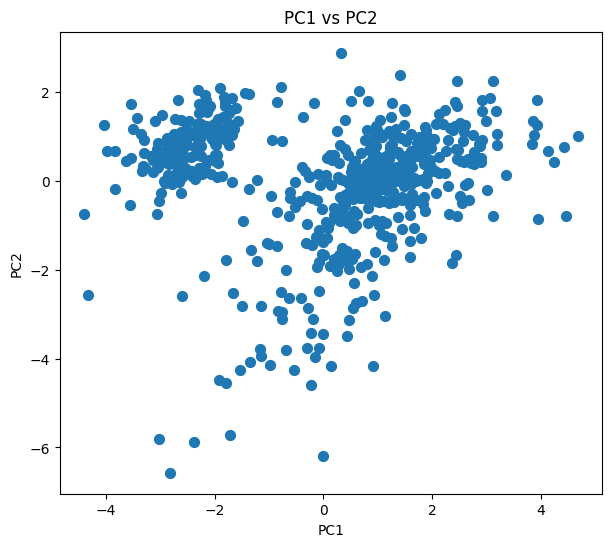

In [87]:
plt.figure(figsize=(7,6))
plt.scatter(scores[:,0], scores[:,1], marker='o', s=50)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PC1 vs PC2')
plt.show()

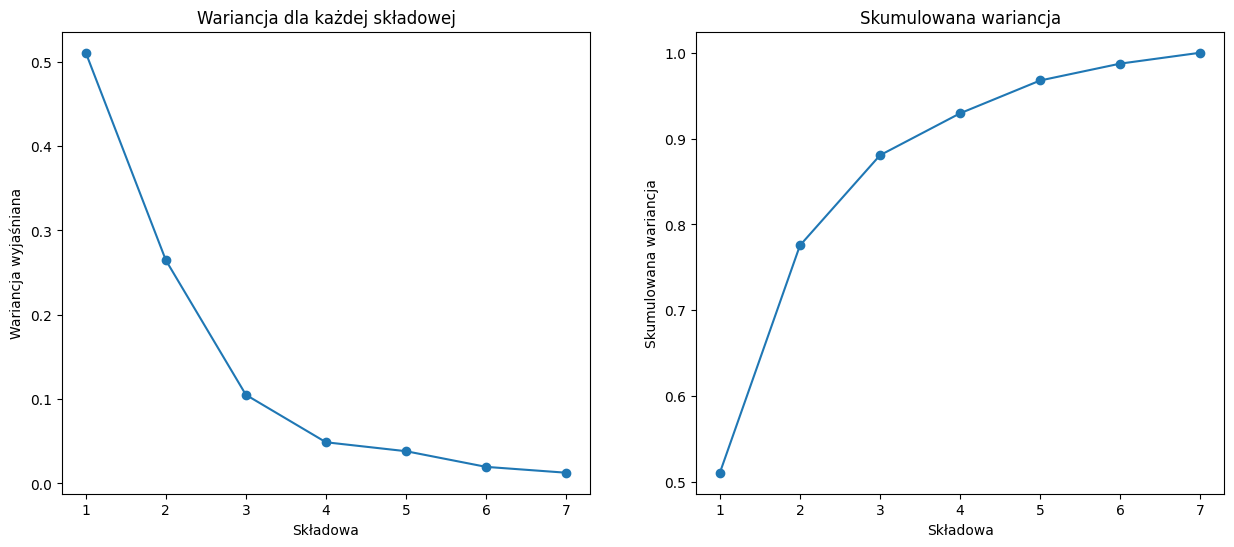

In [88]:
fig, axes = plt.subplots(1, 2, figsize=(15,6))
ticks = np.arange(pca.n_components_) + 1


ax = axes[0]
ax.plot(ticks, pca.explained_variance_ratio_, marker='o')
ax.set_xlabel('Składowa')
ax.set_ylabel('Wariancja wyjaśniana')
ax.set_title('Wariancja dla każdej składowej')


ax = axes[1]
ax.plot(ticks, np.cumsum(pca.explained_variance_ratio_), marker='o')
ax.set_xlabel('Składowa')
ax.set_ylabel('Skumulowana wariancja')
ax.set_title('Skumulowana wariancja')

plt.show()

In [89]:
kmeans = KMeans(n_clusters=10, random_state=2, n_init=20).fit(scaled_data)
labels = kmeans.labels_

counts = pd.Series(labels).value_counts().sort_index()
counts.index = counts.index + 1

print("Liczba obserwacji w każdym klastrze:")
print(counts)

Liczba obserwacji w każdym klastrze:
1      68
2      81
3      30
4      70
5       8
6      92
7      68
8     152
9      18
10     27
Name: count, dtype: int64


In [90]:
variance = []
k_values = range(1, 31)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=2, n_init=30)
    kmeans.fit(scaled_data)

    variance.append(kmeans.inertia_)

In [91]:
df_elbow = pd.DataFrame({
    'Liczba klastrów (k)': list(k_values),
    'Wariancja (Inertia)': variance
})

display(df_elbow)

,Liczba klastrów (k),Wariancja (Inertia)
0,1,4298.000000
1,2,2575.287187
2,3,1825.547900
3,4,1542.033093
4,5,1404.922715
5,6,1306.998980
6,7,1226.623004
7,8,1154.109036
8,9,1103.803372
9,10,1047.698520


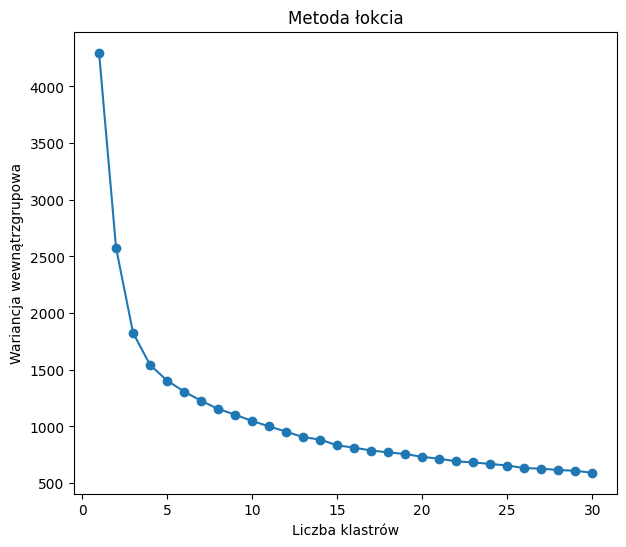

In [92]:
plt.figure(figsize=(7,6))
plt.plot(k_values, variance, marker='o')
plt.xlabel('Liczba klastrów')
plt.ylabel('Wariancja wewnątrzgrupowa')
plt.title('Metoda łokcia')
plt.show()

In [93]:
scores = []
k_range = range(2, 30)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=30).fit(scaled_data)
    score = silhouette_score(scaled_data, kmeans.labels_)
    scores.append(score)

In [94]:
df_silhouette = pd.DataFrame({
    'Liczba klastrów (k)': list(k_range),
    'Silhouette Score': scores
})

display(df_silhouette)

,Liczba klastrów (k),Silhouette Score
0,2,0.430873
1,3,0.450913
2,4,0.326781
3,5,0.308103
4,6,0.309109
5,7,0.215158
6,8,0.211094
7,9,0.182752
8,10,0.191856
9,11,0.200426


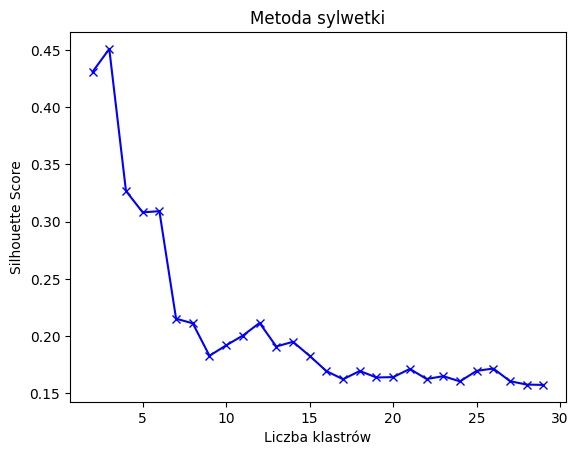

In [95]:
plt.plot(k_range, scores, 'bx-')
plt.title('Metoda sylwetki')
plt.xlabel('Liczba klastrów')
plt.ylabel('Silhouette Score')
plt.show()

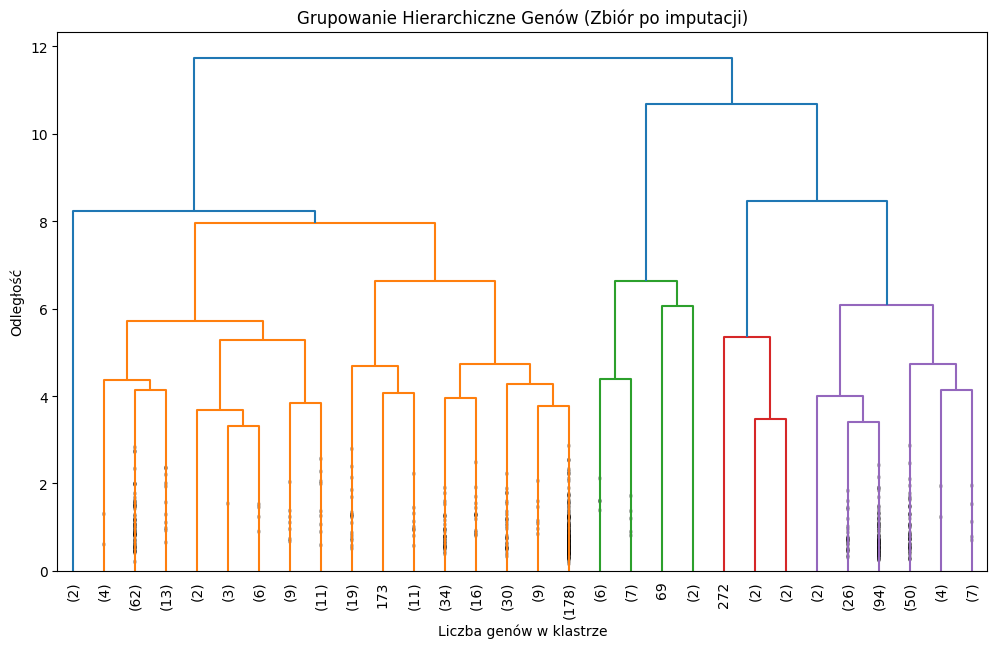

In [96]:
from scipy.cluster.hierarchy import linkage

scaled_data_full = scaler.fit_transform(data_exp_full)
hc_comp = AgglomerativeClustering(distance_threshold=0, n_clusters=None, linkage='complete')
hc_comp.fit(scaled_data_full)
Z = linkage(scaled_data_full, method='complete')

plt.figure(figsize=(12, 7))
plt.title('Grupowanie Hierarchiczne Genów')
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90., leaf_font_size=10., show_contracted=True)
plt.xlabel("Liczba genów w klastrze")
plt.ylabel("Odległość")
plt.show()

In [98]:
sil_scores_hc = []
k_range = range(2, 31)

for k in k_range:
    labels = cut_tree(Z, n_clusters=k).flatten()
    score = silhouette_score(scaled_data_full, labels)
    sil_scores_hc.append(score)


df_sil_hc = pd.DataFrame({
    'Liczba klastrów (k)': list(k_range),
    'Silhouette Score': sil_scores_hc
})
display(df_sil_hc.sort_values(by='Silhouette Score', ascending=False).head(10))

,Liczba klastrów (k),Silhouette Score
2,4,0.444153
1,3,0.440690
3,5,0.440685
0,2,0.428210
4,6,0.361060
5,7,0.358772
6,8,0.330424
8,10,0.233398
7,9,0.233219
11,13,0.211293


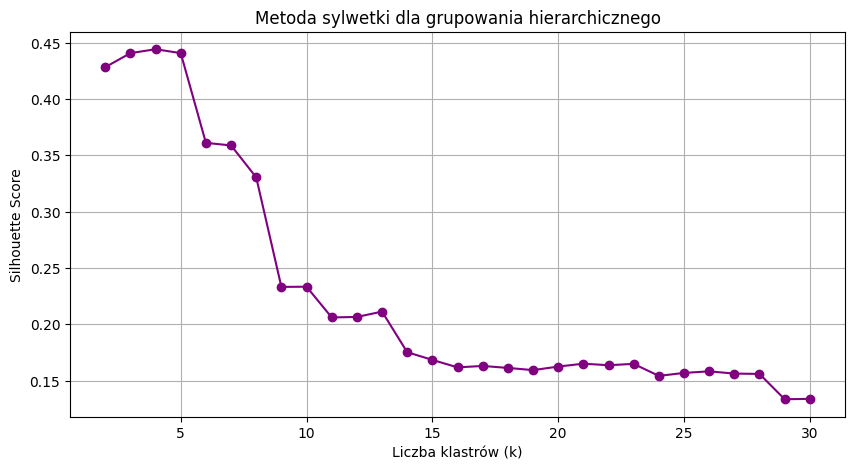

In [99]:
plt.figure(figsize=(10, 5))
plt.plot(k_range, sil_scores_hc, marker='o', color='purple')
plt.title('Metoda sylwetki dla grupowania hierarchicznego')
plt.xlabel('Liczba klastrów (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

In [107]:
kmeans_final = KMeans(n_clusters=3, n_init=20, random_state=42)
kmeans_final.fit(scaled_data_full)
labels_km = kmeans_final.labels_

data_imputed['Cluster_KMeans'] = labels_km

print("Liczebność genów w klastrach (K-Means):")
print(data_imputed['Cluster_KMeans'].value_counts().sort_index())

Liczebność genów w klastrach (K-Means):
Cluster_KMeans
0    345
1    180
2     89
Name: count, dtype: int64


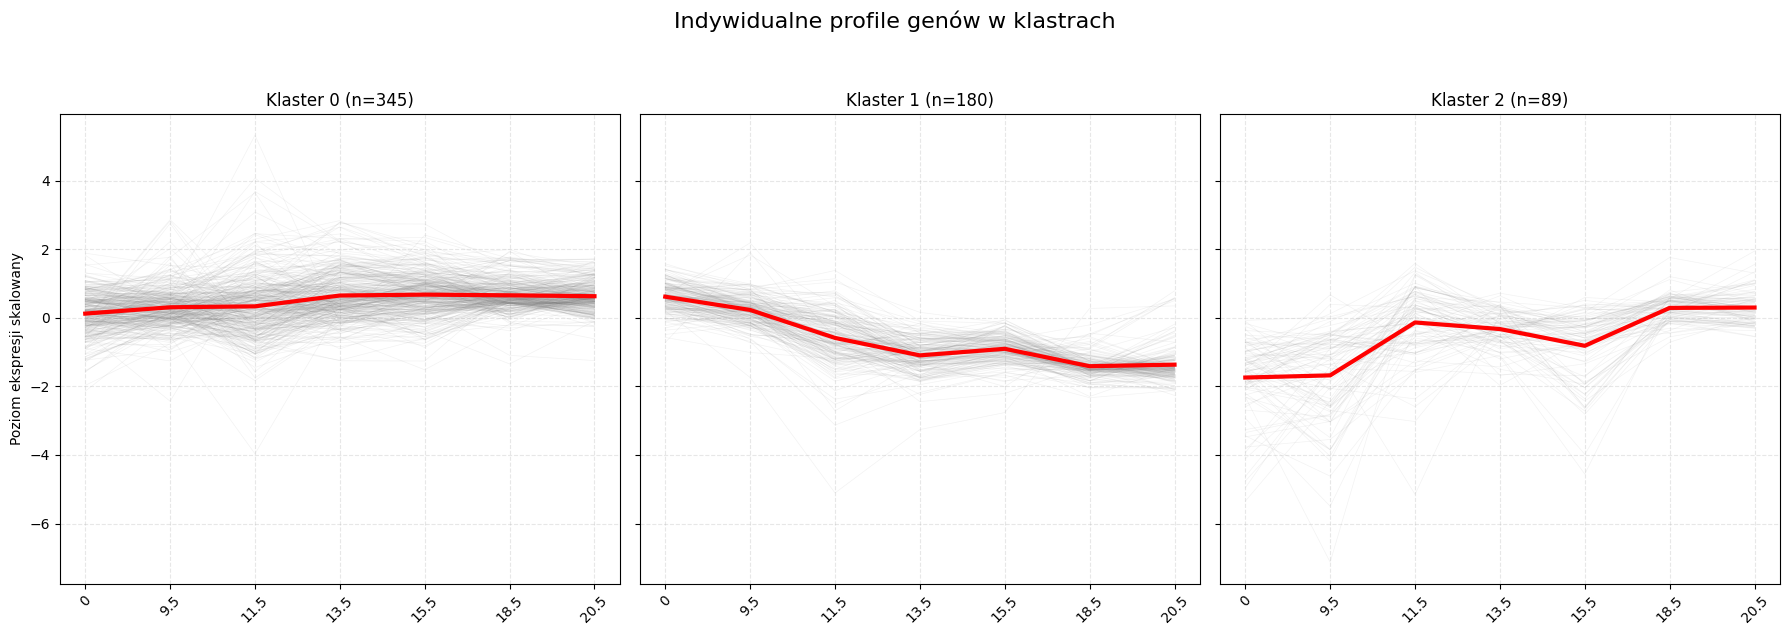

In [108]:
fig, axes_km = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
axes_km = axes_km.flatten()
x_indices = np.arange(7)

for i in range(3):
    ax = axes_km[i]
    cluster_subset = scaled_data_full[labels_km == i]

    for profile in cluster_subset:
        ax.plot(x_indices, profile, color='gray', alpha=0.1, linewidth=0.5)

    mean_profile = cluster_subset.mean(axis=0)
    ax.plot(x_indices, mean_profile, color='red', linewidth=3, label='Średnia')

    ax.set_title(f'Klaster {i} (n={len(cluster_subset)})')
    ax.set_xticks(x_indices)
    ax.set_xticklabels(time_points, rotation=45)
    ax.grid(True, linestyle='--', alpha=0.3)
    if i == 0:
        ax.set_ylabel('Poziom ekspresji skalowany')

plt.suptitle('Indywidualne profile genów w klastrach', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

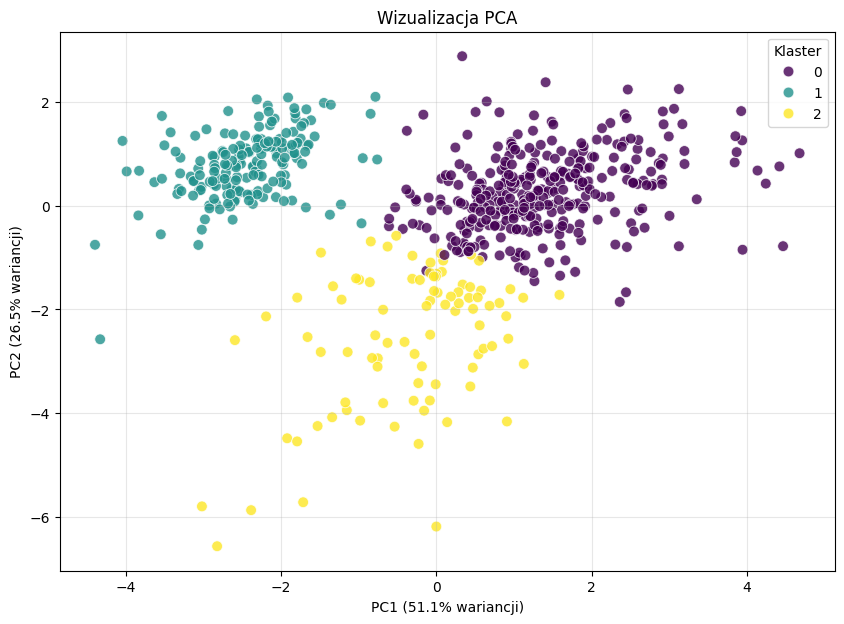

In [109]:
pca_final = PCA(n_components=2)
pca_results = pca_final.fit_transform(scaled_data_full)

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=pca_results[:, 0],
    y=pca_results[:, 1],
    hue=labels_km,
    palette='viridis',
    s=60,
    alpha=0.8
)

plt.title('Wizualizacja PCA')
plt.xlabel(f'PC1 ({pca_final.explained_variance_ratio_[0]:.1%} wariancji)')
plt.ylabel(f'PC2 ({pca_final.explained_variance_ratio_[1]:.1%} wariancji)')
plt.legend(title='Klaster')
plt.grid(True, alpha=0.3)
plt.show()

In [110]:
def predict_gene_cluster(new_profile, scaler_model, kmeans_model):

    profile_reshaped = np.array(new_profile).reshape(1, -1)
    scaled_profile = scaler_model.transform(profile_reshaped)
    cluster_id = kmeans_model.predict(scaled_profile)[0]

    return cluster_id

In [115]:
new_gene = [0.0, 2.5, 2.0, 1.5, 2.0, 2.5, 3.0]

result = predict_gene_cluster(new_gene, scaler, kmeans_final)
print(f"Nowy gen został zaklasyfikowany do: Klaster {result}")

Nowy gen został zaklasyfikowany do: Klaster 0
